In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


In [ ]:
!pip install seaborn


In [ ]:
!pip install matplotlib
!pip install statsmodels


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


In [3]:
df = pd.read_csv("NBA 2024-2025 season - sportsref_(1).csv")


In [4]:
df.head()


,Rk,Team,Games,Wins,Losses,Pythagorean win,Pythagorean Loss,3P,3Pt Attempt,3P%,3Pt Attempt Rate,Margin of Victory,Pace Factor
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,Atlanta Hawks,82.0,40.0,42.0,38.0,44.0,13.5,37.7,0.358,0.410,-1.13,102.6
2,8.0,Boston Celtics*,82.0,61.0,21.0,62.0,20.0,17.8,48.2,0.368,0.536,9.11,95.7
3,30.0,Brooklyn Nets,82.0,26.0,56.0,23.0,59.0,13.6,39.4,0.344,0.458,-7.11,96.4
4,29.0,Charlotte Hornets,82.0,19.0,63.0,20.0,62.0,13.0,38.3,0.339,0.430,-9.11,97.6


In [5]:
df.tail()     # last 5 teams
len(df)       # should be 30


31

In [6]:
df = df.dropna(subset=["Team"]).copy()
df.head()


,Rk,Team,Games,Wins,Losses,Pythagorean win,Pythagorean Loss,3P,3Pt Attempt,3P%,3Pt Attempt Rate,Margin of Victory,Pace Factor
1,5.0,Atlanta Hawks,82.0,40.0,42.0,38.0,44.0,13.5,37.7,0.358,0.410,-1.13,102.6
2,8.0,Boston Celtics*,82.0,61.0,21.0,62.0,20.0,17.8,48.2,0.368,0.536,9.11,95.7
3,30.0,Brooklyn Nets,82.0,26.0,56.0,23.0,59.0,13.6,39.4,0.344,0.458,-7.11,96.4
4,29.0,Charlotte Hornets,82.0,19.0,63.0,20.0,62.0,13.0,38.3,0.339,0.430,-9.11,97.6
5,6.0,Chicago Bulls,82.0,39.0,43.0,37.0,45.0,15.4,42.0,0.367,0.457,-1.56,102.8


In [7]:
len(df)


30

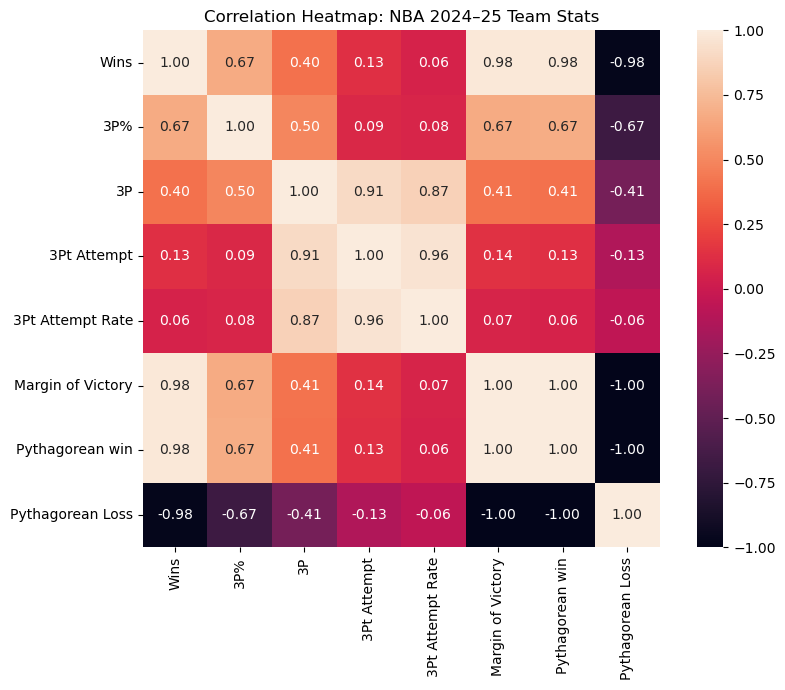

In [8]:
corr_cols = ["Wins","3P%","3P","3Pt Attempt","3Pt Attempt Rate",
             "Margin of Victory","Pythagorean win","Pythagorean Loss"]

corr = df[corr_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Heatmap: NBA 2024–25 Team Stats")
plt.tight_layout()
plt.show()


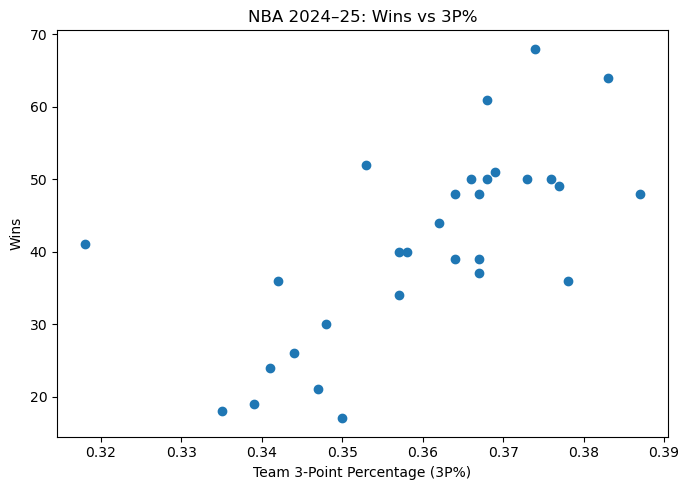

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(df["3P%"], df["Wins"])
plt.xlabel("Team 3-Point Percentage (3P%)")
plt.ylabel("Wins")
plt.title("NBA 2024–25: Wins vs 3P%")
plt.tight_layout()
plt.show()


In [10]:
y = df["Wins"]
X = df["3P%"]
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Wins   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     22.84
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           5.07e-05
Time:                        12:29:29   Log-Likelihood:                -110.87
No. Observations:                  30   AIC:                             225.7
Df Residuals:                      28   BIC:                             228.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -163.8433     42.903     -3.819      0.001    -251.725     -75.961
3P%          569.0619    119.075      4.779      0.000     325.148     812.976
==============================================================================
Omnibus:                        1.764   Durbin-Watson:                   1.413
Prob(Omnibus):                  0.414   Jarque-Bera (JB):                1.212
Skew:                           0.492   Prob(JB):                        0.546
Kurtosis:                       2.954   Cond. No.                         73.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""